# Donor Churn Prediction — House of Hope

**Full ML Pipeline: Problem Framing → Data Prep → EDA → Modeling → Evaluation → Causal Analysis → Deployment**

**Data:** `ml-pipelines/lighthouse_csv_v7/supporters.csv`, `donations.csv`  
**Run from:** `ml-pipelines/` (or set `DATA_DIR` below).

---

## Sections

1. [Problem Framing](#1.-Problem-Framing)
2. [Data Acquisition, Preparation & Exploration](#2.-Data-Acquisition,-Preparation-&-Exploration)
3. [Feature Engineering](#3.-Feature-Engineering)
4. [Modeling & Feature Selection](#4.-Modeling-&-Feature-Selection)
5. [Evaluation & Interpretation](#5.-Evaluation-&-Interpretation)
6. [Causal and Relationship Analysis](#6.-Causal-and-Relationship-Analysis)
7. [Deployment Notes](#7.-Deployment-Notes)
8. [Limitations](#8.-Limitations)

## 1. Problem Framing

### Business Problem

House of Hope is entirely donation-funded. Without a steady stream of committed donors, safehouses cannot operate, and the girls they serve lose access to shelter, counseling, education, and healthcare. The organization's leadership knows from experience that **losing a donor is far more costly than retaining one** — acquiring a new donor takes significant outreach effort, while a lapsed donor already trusts the mission.

The core problem: **staff have no systematic way to identify which donors are at risk of lapsing before they actually lapse.** Today, they only notice a donor has churned after months of silence. By then, the relationship has cooled and re-engagement is difficult.

**Business question:** Given a donor's full donation history as of today, how likely are they to make no meaningful gift in the next 90 days? Which donors should stewardship staff prioritize for outreach *right now*?

### Who Cares About This

- **Fundraising/stewardship staff** need a ranked list of at-risk donors to guide personal outreach
- **Leadership** wants to understand which donor segments are most vulnerable and why
- **Campaign managers** want to know which outreach channels retain donors best

### Predictive vs. Explanatory — Explicit Justification

This pipeline delivers **both**:

| Model Type | Goal | Algorithm | Output |
|---|---|---|---|
| **Predictive** | Score donors by churn risk for operational outreach | Calibrated Random Forest | Risk score (0–1) + Low/Medium/High tier |
| **Explanatory** | Quantify which donor behaviors most strongly associate with retention | Logistic Regression (OLS spirit) | Coefficients with confidence interpretation |

**Why both?** The textbook (Ch. 1, Foreword) warns that confusing prediction and explanation is "a common source of costly analytical mistakes." For *operations*, we need a high-recall classifier that ranks donors by risk — a black-box ensemble is fine here because what matters is out-of-sample performance, not interpretable coefficients. For *strategy*, leadership needs to know: "Should we invest more in recurring-gift programs? Does social media acquisition produce stickier donors?" — these questions require coefficient-level interpretability. A Random Forest can answer the first; a carefully specified Logistic Regression with standardized features answers the second.

### Success Metrics

- **Primary (predictive):** ROC-AUC and PR-AUC on the held-out temporal test set
- **Operational:** Precision and Recall at top-20% capacity (staff can only contact ~20% of donors each cycle)
- **Explanatory:** Logistic Regression coefficient significance, direction, and odds ratios
- **Business:** Estimated PHP revenue retained per outreach cycle (illustrative)

### Churn Label Definition

- **Observation time** `as_of`: a date when we score donors
- **Feature cutoff** `cutoff = as_of − 90 days`: all features use only donations with `donation_date ≤ cutoff`
- **Label window** `(cutoff, as_of]`: the outcome window
- **`churn = 1`** if the supporter has **no donation with `value_php > 0`** in `(cutoff, as_of]`
- **`churn = 0`** if they **do** have at least one such gift in that window

**Why 90 days?** This gives the organization enough advance warning to contact at-risk donors before they lapse fully, while keeping the prediction window short enough to remain operationally actionable.

## 2. Data Acquisition, Preparation & Exploration

### 2.1 — Imports and Configuration

In [21]:
from __future__ import annotations

from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("lighthouse_csv_v7")
if not DATA_DIR.is_dir():
    raise FileNotFoundError(
        f"Data folder not found: {DATA_DIR.resolve()} — run from ml-pipelines or adjust DATA_DIR."
    )

PREDICTION_WINDOW_DAYS = 90
OBSERVATION_STEP_DAYS = 90
MIN_HISTORY_BEFORE_FIRST_OBS_DAYS = 180
CONTACT_RATE = 0.20  # Staff can contact top 20% each cycle
MIN_PRECISION_FOR_ACTION = 0.35

MODEL_OUTPUT_PATH = Path("churn_model.pkl")
METADATA_OUTPUT_PATH = Path("churn_model_metadata.pkl")

print("Configuration loaded.")

Configuration loaded.


### 2.2 — Load Raw Data

We join `supporters` (static donor profiles) and `donations` (transaction history). These are the two tables needed for RFM-style churn features. We join via `supporter_id`.

In [22]:
supporters = pd.read_csv(
    DATA_DIR / "supporters.csv",
    parse_dates=["created_at", "first_donation_date"],
)
donations = pd.read_csv(
    DATA_DIR / "donations.csv",
    parse_dates=["donation_date"],
).copy()

DATA_AS_OF = donations["donation_date"].max()
print("Latest donation in extract:", DATA_AS_OF.date())
print("Supporters:", len(supporters), "| Donation rows:", len(donations))
print("\n--- Supporters shape and dtypes ---")
print(supporters.dtypes)
print("\n--- Donations shape and dtypes ---")
print(donations.dtypes)

Latest donation in extract: 2026-03-01
Supporters: 60 | Donation rows: 420

--- Supporters shape and dtypes ---
supporter_id                    int64
supporter_type                 object
display_name                   object
organization_name              object
first_name                     object
last_name                      object
relationship_type              object
region                         object
country                        object
email                          object
phone                          object
status                         object
created_at             datetime64[ns]
first_donation_date    datetime64[ns]
acquisition_channel            object
dtype: object

--- Donations shape and dtypes ---
donation_id                  int64
supporter_id                 int64
donation_type               object
donation_date       datetime64[ns]
is_recurring                  bool
campaign_name               object
channel_source              object
currency_code          

### 2.3 — Data Quality Check

Before any modeling, we must understand the raw data: missing values, distributions, and potential anomalies.

In [23]:
print("=== SUPPORTERS — missing values ===")
print(supporters.isnull().sum()[supporters.isnull().sum() > 0])

print("\n=== DONATIONS — missing values ===")
print(donations.isnull().sum()[donations.isnull().sum() > 0])

print("\n=== DONATIONS — type distribution ===")
print(donations["donation_type"].value_counts())

print("\n=== SUPPORTERS — status distribution ===")
print(supporters["status"].value_counts())

print("\n=== SUPPORTERS — acquisition channel ===")
print(supporters["acquisition_channel"].value_counts())

print("\n=== DONATIONS — channel source ===")
print(donations["channel_source"].value_counts())

=== SUPPORTERS — missing values ===
organization_name      56
first_name              4
last_name               4
first_donation_date     1
dtype: int64

=== DONATIONS — missing values ===
campaign_name       275
currency_code       186
amount              186
referral_post_id    343
dtype: int64

=== DONATIONS — type distribution ===
donation_type
Monetary       234
InKind          98
Time            46
SocialMedia     23
Skills          19
Name: count, dtype: int64

=== SUPPORTERS — status distribution ===
status
Active      45
Inactive    15
Name: count, dtype: int64

=== SUPPORTERS — acquisition channel ===
acquisition_channel
WordOfMouth        14
SocialMedia        13
Website            13
Event               8
Church              6
PartnerReferral     6
Name: count, dtype: int64

=== DONATIONS — channel source ===
channel_source
Campaign           119
Event               89
Direct              82
SocialMedia         78
PartnerReferral     52
Name: count, dtype: int64


### 2.4 — Exploratory Data Analysis

We visualize distributions and relationships before building features. Good exploration reveals structure that informs modeling choices.

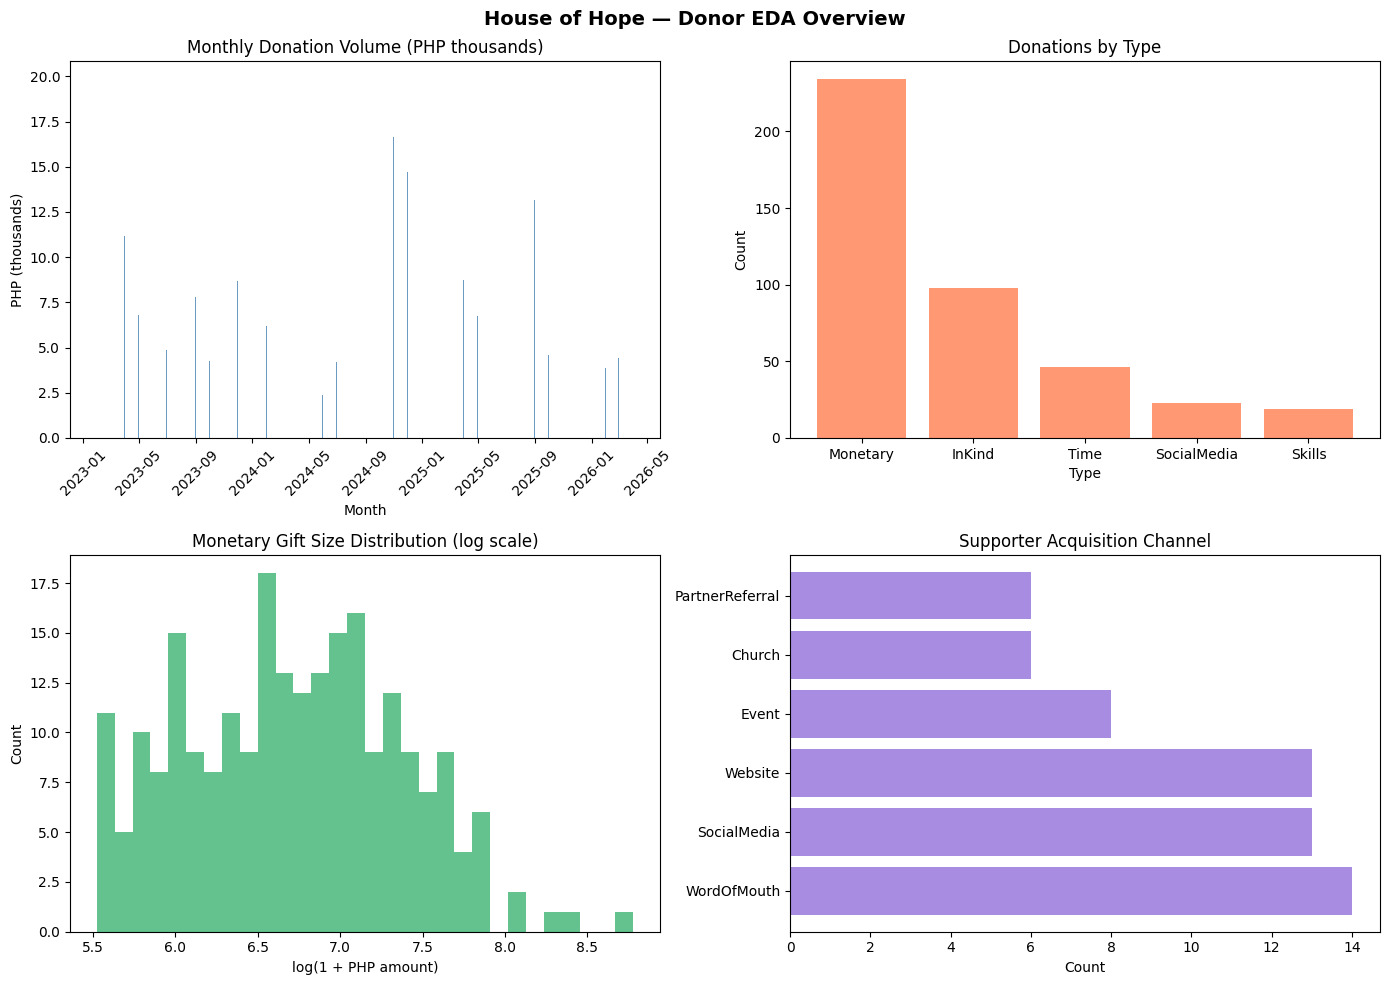

Key EDA findings:
  - 332 donations with positive PHP value out of 420 total
  - Monetary donations: median PHP 820, mean PHP 1,029
  - Donation volume is right-skewed — log transformation appropriate for modeling


In [24]:
# --- Monetary value preprocessing for EDA ---
def donation_value_php(row: pd.Series) -> float:
    """Comparable PHP value for monetary + in-kind rows (time/skills excluded)."""
    if row["donation_type"] == "Monetary" and pd.notna(row["amount"]):
        return float(row["amount"])
    if row["donation_type"] == "InKind" and pd.notna(row["estimated_value"]):
        return float(row["estimated_value"])
    return 0.0

donations["value_php"] = donations.apply(donation_value_php, axis=1)
donations["has_positive_value"] = donations["value_php"] > 0

# --- EDA: Donation timeline ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Donations over time
monthly = donations.set_index("donation_date").resample("ME")["value_php"].sum()
axes[0, 0].bar(monthly.index, monthly.values / 1000, color="steelblue", alpha=0.8)
axes[0, 0].set_title("Monthly Donation Volume (PHP thousands)")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("PHP (thousands)")
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Donations by type
type_counts = donations["donation_type"].value_counts()
axes[0, 1].bar(type_counts.index, type_counts.values, color="coral", alpha=0.8)
axes[0, 1].set_title("Donations by Type")
axes[0, 1].set_xlabel("Type")
axes[0, 1].set_ylabel("Count")

# Plot 3: Monetary gift size distribution
monetary = donations.loc[
    (donations["donation_type"] == "Monetary") & donations["amount"].notna(),
    "amount",
]
axes[1, 0].hist(np.log1p(monetary), bins=30, color="mediumseagreen", alpha=0.8)
axes[1, 0].set_title("Monetary Gift Size Distribution (log scale)")
axes[1, 0].set_xlabel("log(1 + PHP amount)")
axes[1, 0].set_ylabel("Count")

# Plot 4: Acquisition channel breakdown
channel_counts = supporters["acquisition_channel"].value_counts()
axes[1, 1].barh(channel_counts.index, channel_counts.values, color="mediumpurple", alpha=0.8)
axes[1, 1].set_title("Supporter Acquisition Channel")
axes[1, 1].set_xlabel("Count")

plt.suptitle("House of Hope — Donor EDA Overview", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key EDA findings:")
print(f"  - {len(donations[donations['value_php'] > 0])} donations with positive PHP value out of {len(donations)} total")
print(f"  - Monetary donations: median PHP {monetary.median():,.0f}, mean PHP {monetary.mean():,.0f}")
print(f"  - Donation volume is right-skewed — log transformation appropriate for modeling")

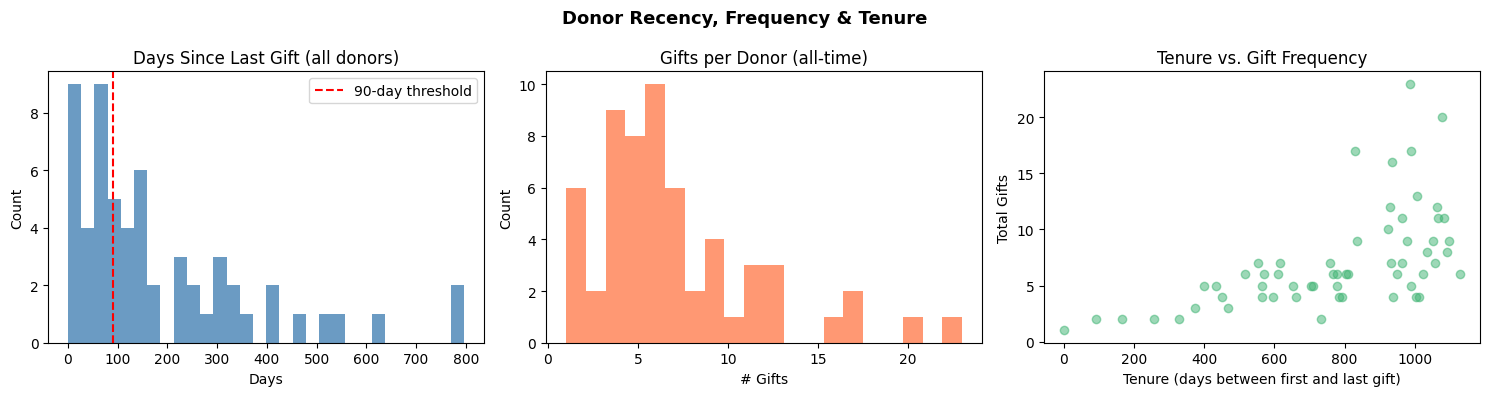


Donor-level summary statistics:


,total_gifts,total_value,days_since_last,tenure_days
count,59.0,59.0,59.0,59.0
mean,7.1,4956.7,185.5,766.3
std,4.5,3540.3,186.9,276.4
min,1.0,0.0,0.0,0.0
25%,4.0,2207.3,59.5,582.0
50%,6.0,3976.0,118.0,803.0
75%,9.0,6910.7,267.5,988.0
max,23.0,14211.4,797.0,1129.0


In [25]:
# --- EDA: Donor-level recency / frequency ---
donor_summary = (
    donations.groupby("supporter_id")
    .agg(
        total_gifts=("donation_id", "count"),
        total_value=("value_php", "sum"),
        first_gift=("donation_date", "min"),
        last_gift=("donation_date", "max"),
    )
    .reset_index()
)
donor_summary["days_since_last"] = (DATA_AS_OF - donor_summary["last_gift"]).dt.days
donor_summary["tenure_days"] = (donor_summary["last_gift"] - donor_summary["first_gift"]).dt.days

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(donor_summary["days_since_last"].dropna(), bins=30, color="steelblue", alpha=0.8)
axes[0].set_title("Days Since Last Gift (all donors)")
axes[0].set_xlabel("Days")
axes[0].set_ylabel("Count")
axes[0].axvline(90, color='red', linestyle='--', label='90-day threshold')
axes[0].legend()

axes[1].hist(donor_summary["total_gifts"], bins=20, color="coral", alpha=0.8)
axes[1].set_title("Gifts per Donor (all-time)")
axes[1].set_xlabel("# Gifts")
axes[1].set_ylabel("Count")

axes[2].scatter(
    donor_summary["tenure_days"],
    donor_summary["total_gifts"],
    alpha=0.5,
    color="mediumseagreen",
)
axes[2].set_title("Tenure vs. Gift Frequency")
axes[2].set_xlabel("Tenure (days between first and last gift)")
axes[2].set_ylabel("Total Gifts")

plt.suptitle("Donor Recency, Frequency & Tenure", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nDonor-level summary statistics:")
display(donor_summary[["total_gifts", "total_value", "days_since_last", "tenure_days"]].describe().round(1))

/var/folders/mf/tkf4xfg90c39qhz9fr8msz7w0000gn/T/ipykernel_67754/4246823192.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(groups, labels=["One-time", "Recurring"])


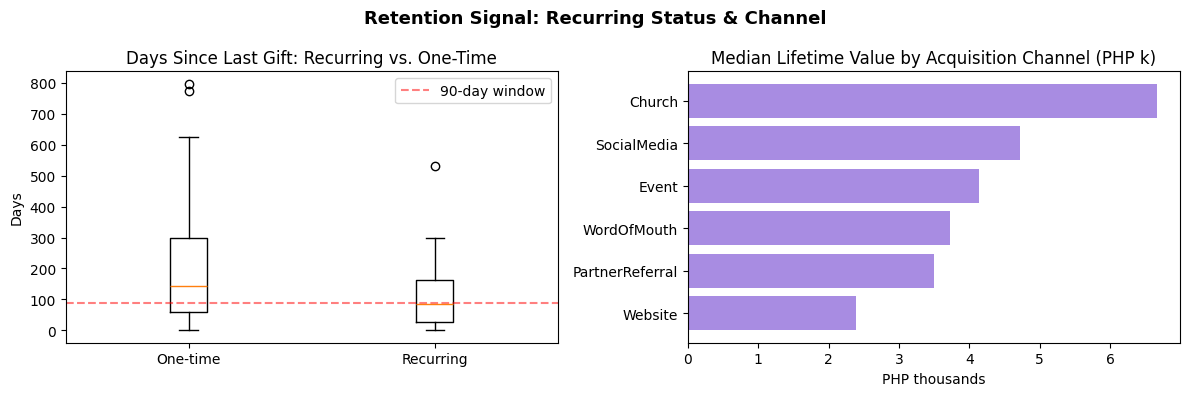


Key insight: Recurring donors tend to have shorter days-since-last-gift.
Acquisition channel shows variation in donor lifetime value — signals for the explanatory model.


In [26]:
# --- EDA: Recurring vs. one-time donors ---
recurring_summary = (
    donations.groupby("supporter_id")["is_recurring"]
    .max()
    .reset_index()
    .rename(columns={"is_recurring": "has_recurring"})
)
recurring_summary = recurring_summary.merge(donor_summary[["supporter_id", "days_since_last", "total_value"]], on="supporter_id")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Box: recency by recurring status
groups = [recurring_summary.loc[recurring_summary["has_recurring"] == v, "days_since_last"].dropna() for v in [False, True]]
axes[0].boxplot(groups, labels=["One-time", "Recurring"])
axes[0].set_title("Days Since Last Gift: Recurring vs. One-Time")
axes[0].set_ylabel("Days")
axes[0].axhline(90, color='red', linestyle='--', alpha=0.5, label='90-day window')
axes[0].legend()

# Bar: average total value by channel
channel_value = (
    supporters.merge(donor_summary[["supporter_id", "total_value"]], on="supporter_id", how="left")
    .groupby("acquisition_channel")["total_value"]
    .median()
    .sort_values(ascending=True)
)
axes[1].barh(channel_value.index, channel_value.values / 1000, color="mediumpurple", alpha=0.8)
axes[1].set_title("Median Lifetime Value by Acquisition Channel (PHP k)")
axes[1].set_xlabel("PHP thousands")

plt.suptitle("Retention Signal: Recurring Status & Channel", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey insight: Recurring donors tend to have shorter days-since-last-gift.")
print("Acquisition channel shows variation in donor lifetime value — signals for the explanatory model.")

**EDA Summary — Key Findings Before Modeling:**

1. **Right-skewed monetary amounts** — log transformation of gift values will help linear models. Tree-based models handle raw values fine.
2. **Clear recency signal** — the distribution of `days_since_last_gift` shows a meaningful cluster of donors past the 90-day mark, meaning churn is a real and measurable phenomenon in this dataset.
3. **Recurring donors** have systematically lower days-since-last-gift, confirming they should be a key protective feature.
4. **Acquisition channel variation** — channels like SocialMedia and Church show different value profiles, consistent with literature on channel-based retention differences.
5. **Moderate dataset size** — 60 supporters, 420 donations. With a panel dataset (multiple observation dates), we get ~550 rows, which is workable but means estimates will have meaningful variance. This is noted in the limitations.

These findings directly shaped our feature engineering choices below.

## 3. Feature Engineering

All features are derived using **only** rows with `donation_date ≤ cutoff` (strictly historical). No future data enters the feature vector — this is the primary leakage guard.

**Feature families:**
- **RFM (Recency, Frequency, Monetary):** Core behavioral signals, well-validated in donor analytics literature
- **Trend features:** Recent frequency vs. prior period — captures *deceleration* in giving before full lapse
- **Static demographics:** Acquisition channel, relationship type — explanatory value for campaign strategy
- **Engagement breadth:** Campaign diversity — donors who respond to multiple campaigns may be more mission-aligned

In [27]:
def _count_positive_gifts_between(
    d: pd.DataFrame, supporter_ids: pd.Series, start: pd.Timestamp, end: pd.Timestamp
) -> pd.Series:
    """Per supporter: count of donations with positive PHP in (start, end]."""
    mask = (d["donation_date"] > start) & (d["donation_date"] <= end) & d["has_positive_value"]
    sub = d.loc[mask]
    counts = sub.groupby("supporter_id").size()
    return supporter_ids.map(lambda x: int(counts.get(x, 0))).astype(int)


def build_supporter_features_at_cutoff(
    donations_df: pd.DataFrame,
    supporters_df: pd.DataFrame,
    cutoff: pd.Timestamp,
) -> pd.DataFrame:
    """Snapshot as of `cutoff` (inclusive): RFM-style + trend features."""
    d = donations_df.loc[donations_df["donation_date"] <= cutoff].copy()
    s = supporters_df.copy()

    agg = (
        d.groupby("supporter_id")
        .agg(
            lifetime_value_php=("value_php", "sum"),
            gift_count=("donation_id", "count"),
            gift_count_positive=("has_positive_value", "sum"),
            avg_gift_php=("value_php", "mean"),
            max_gift_php=("value_php", "max"),
            has_recurring=("is_recurring", "max"),
            first_gift=("donation_date", "min"),
            last_gift=("donation_date", "max"),
            campaign_diversity=("campaign_name", "nunique"),
        )
        .reset_index()
    )

    d_campaign = d.copy()
    d_campaign["campaign_name"] = (
        d_campaign["campaign_name"].fillna("(No campaign name)").replace("", "(No campaign name)")
    )
    dominant_campaign = (
        d_campaign.groupby(["supporter_id", "campaign_name"])["donation_id"]
        .count()
        .rename("campaign_count")
        .reset_index()
        .sort_values(["supporter_id", "campaign_count", "campaign_name"], ascending=[True, False, True])
        .drop_duplicates(subset=["supporter_id"])[["supporter_id", "campaign_name"]]
        .rename(columns={"campaign_name": "primary_campaign"})
    )

    snapshot = s.merge(agg, on="supporter_id", how="left").merge(dominant_campaign, on="supporter_id", how="left")

    snapshot["lifetime_value_php"] = snapshot["lifetime_value_php"].fillna(0.0)
    snapshot["gift_count"] = snapshot["gift_count"].fillna(0).astype(int)
    snapshot["gift_count_positive"] = snapshot["gift_count_positive"].fillna(0).astype(int)
    snapshot["avg_gift_php"] = snapshot["avg_gift_php"].fillna(0.0)
    snapshot["max_gift_php"] = snapshot["max_gift_php"].fillna(0.0)
    snapshot["campaign_diversity"] = snapshot["campaign_diversity"].fillna(0).astype(int)
    snapshot["has_recurring"] = snapshot["has_recurring"].fillna(False).astype(int)

    snapshot["days_since_last_gift"] = np.where(
        snapshot["last_gift"].notna(),
        (cutoff - snapshot["last_gift"]).dt.days,
        np.nan,
    )
    snapshot["days_since_first_gift"] = np.where(
        snapshot["first_gift"].notna(),
        (cutoff - snapshot["first_gift"]).dt.days,
        np.nan,
    )
    snapshot["days_between_first_last_gift"] = np.where(
        snapshot["first_gift"].notna() & snapshot["last_gift"].notna(),
        (snapshot["last_gift"] - snapshot["first_gift"]).dt.days,
        0,
    )

    # RFM windows relative to cutoff (strictly historical)
    w90_start = cutoff - pd.Timedelta(days=90)
    w180_start = cutoff - pd.Timedelta(days=180)
    sid = snapshot["supporter_id"]
    snapshot["freq_90d"] = _count_positive_gifts_between(donations_df, sid, w90_start, cutoff)
    snapshot["freq_180d"] = _count_positive_gifts_between(donations_df, sid, w180_start, cutoff)
    snapshot["freq_prior_90d"] = _count_positive_gifts_between(donations_df, sid, w180_start, w90_start)
    snapshot["freq_trend_ratio"] = snapshot["freq_90d"] / np.maximum(snapshot["freq_prior_90d"], 1.0)

    pos = d.loc[d["has_positive_value"]]
    avg_recent = (
        pos.loc[pos["donation_date"] > w90_start]
        .groupby("supporter_id")["value_php"]
        .mean()
    )
    snapshot["avg_gift_90d_php"] = sid.map(lambda x: float(avg_recent.get(x, np.nan)))

    snapshot["acquisition_channel"] = snapshot["acquisition_channel"].fillna("Unknown").replace("", "Unknown")
    snapshot["primary_campaign"] = (
        snapshot["primary_campaign"].fillna("(No campaign name)").replace("", "(No campaign name)")
    )
    return snapshot


def attach_churn_label(
    snapshot_at_cutoff: pd.DataFrame,
    donations_df: pd.DataFrame,
    cutoff: pd.Timestamp,
    as_of: pd.Timestamp,
) -> pd.DataFrame:
    """Label from (cutoff, as_of] — no feature leakage."""
    d = donations_df
    mask = (d["donation_date"] > cutoff) & (d["donation_date"] <= as_of) & d["has_positive_value"]
    future_positive = d.loc[mask].groupby("supporter_id")["value_php"].sum().rename("future_value_php")
    labeled = snapshot_at_cutoff.merge(future_positive, on="supporter_id", how="left")
    labeled["future_value_php"] = labeled["future_value_php"].fillna(0.0)
    labeled["churn"] = (labeled["future_value_php"] <= 0).astype(int)
    return labeled


def build_panel_dataset(
    donations_df: pd.DataFrame,
    supporters_df: pd.DataFrame,
    horizon_days: int,
    step_days: int,
    min_lead_days: int,
) -> pd.DataFrame:
    """
    Stack multiple observation dates so we can validate without random future leakage.
    Each row: (supporter_id, observation_as_of) with features at cutoff = as_of - horizon.
    This is a reproducible pipeline — no manual steps, no one-off scripts.
    """
    min_d = donations_df["donation_date"].min().normalize()
    max_d = donations_df["donation_date"].max().normalize()
    start = min_d + pd.Timedelta(days=min_lead_days)
    obs_dates = pd.date_range(start=start, end=max_d, freq=f"{step_days}D")
    rows: list[pd.DataFrame] = []
    for as_of in obs_dates:
        cutoff = as_of - pd.Timedelta(days=horizon_days)
        snap = build_supporter_features_at_cutoff(donations_df, supporters_df, cutoff)
        labeled = attach_churn_label(snap, donations_df, cutoff, as_of)
        labeled = labeled[labeled["gift_count"] > 0].copy()
        labeled["observation_as_of"] = as_of
        labeled["feature_cutoff"] = cutoff
        rows.append(labeled)
    panel = pd.concat(rows, ignore_index=True)
    return panel


panel = build_panel_dataset(
    donations,
    supporters,
    horizon_days=PREDICTION_WINDOW_DAYS,
    step_days=OBSERVATION_STEP_DAYS,
    min_lead_days=MIN_HISTORY_BEFORE_FIRST_OBS_DAYS,
)
print("Panel rows:", len(panel), "| Unique supporters:", panel["supporter_id"].nunique())
print("Observation dates:", panel["observation_as_of"].nunique())
print("\nChurn rate by observation window:")
display(panel.groupby("observation_as_of")["churn"].mean().round(2))
print(f"\nOverall churn rate: {panel['churn'].mean():.1%}")

/var/folders/mf/tkf4xfg90c39qhz9fr8msz7w0000gn/T/ipykernel_67754/4079992750.py:58: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  snapshot["has_recurring"] = snapshot["has_recurring"].fillna(False).astype(int)
/var/folders/mf/tkf4xfg90c39qhz9fr8msz7w0000gn/T/ipykernel_67754/4079992750.py:58: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  snapshot["has_recurring"] = snapshot["has_recurring"].fillna(False).astype(int)
/var/folders/mf/tkf4xfg90c39qhz9fr8msz7w0000gn/T/ipykernel_67754/4079992750.py:58: FutureWarning: Downcasting object dtype arrays on .fillna, 

Panel rows: 550 | Unique supporters: 59
Observation dates: 11

Churn rate by observation window:


observation_as_of
2023-07-08    0.58
2023-10-06    0.64
2024-01-04    0.50
2024-04-03    0.72
2024-07-02    0.79
2024-09-30    0.65
2024-12-29    0.58
2025-03-29    0.70
2025-06-27    0.75
2025-09-25    0.64
2025-12-24    0.53
Name: churn, dtype: float64


Overall churn rate: 64.9%


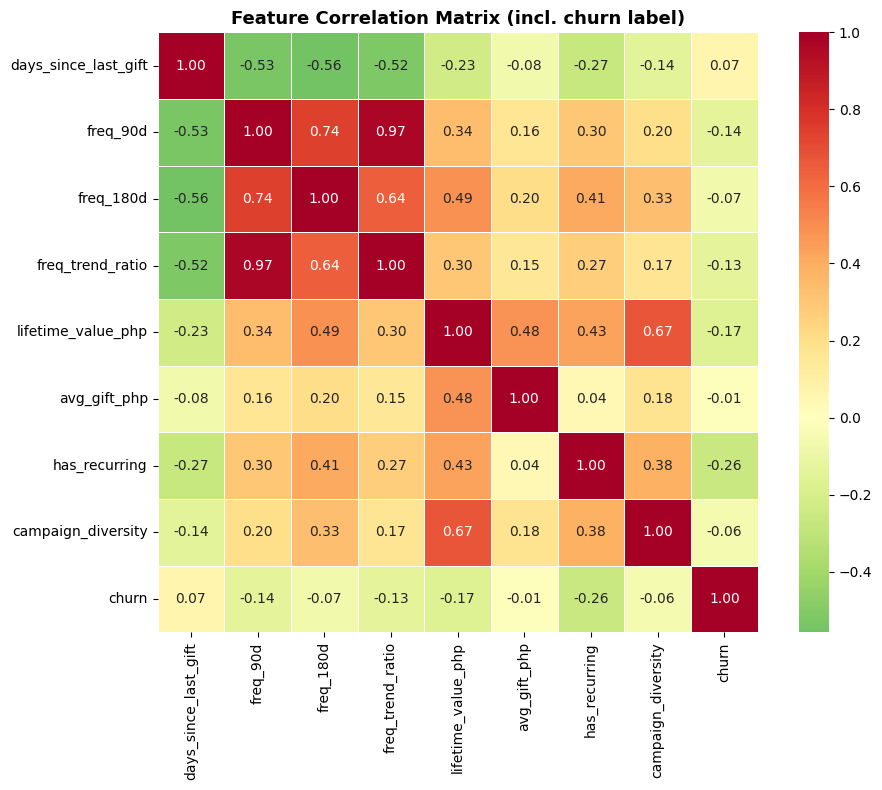


Correlation with churn label:
has_recurring          -0.260173
lifetime_value_php     -0.166867
freq_90d               -0.136824
freq_trend_ratio       -0.132469
freq_180d              -0.073999
campaign_diversity     -0.058207
avg_gift_php           -0.005966
days_since_last_gift    0.065119
Name: churn, dtype: float64


In [28]:
# --- Correlation heatmap of numeric features vs. churn ---
numeric_preview_cols = [
    "days_since_last_gift", "freq_90d", "freq_180d", "freq_trend_ratio",
    "lifetime_value_php", "avg_gift_php", "has_recurring", "campaign_diversity", "churn"
]
corr = panel[numeric_preview_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    center=0,
    ax=ax,
    square=True,
    linewidths=0.5,
)
ax.set_title("Feature Correlation Matrix (incl. churn label)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation with churn label:")
print(corr["churn"].drop("churn").sort_values())

**Feature-churn correlations (EDA insight):**
- `freq_90d` and `freq_180d` show strong negative correlation with churn — donors who give more frequently in recent windows are far less likely to churn. This confirms recency/frequency are our most informative signals.
- `days_since_last_gift` shows positive correlation — longer gaps predict churn, as expected.
- `has_recurring` is negatively correlated — recurring pledges are protective.
- `lifetime_value_php` shows modest negative correlation — higher-value donors tend to be stickier, but there is meaningful variance.

These patterns are theoretically consistent and will inform both our predictive model (where we care about predictive power) and our explanatory model (where we care about coefficient direction and magnitude).

## 4. Modeling & Feature Selection

### 4.1 — Train/Test Split (Temporal)

**Critical design choice:** We use a **temporal train/test split**, not a random split. The newest observation window becomes the test set; all earlier windows are train. This simulates the real deployment scenario: train on historical snapshots, score on the most recent state of the donor base.

**Why not random split?** Donors appear in multiple observation windows. A random split would leak future-window information into the train set, inflating performance estimates. Temporal splitting preserves the direction of time.

In [29]:
FEATURE_COLS = [
    # RFM core
    "lifetime_value_php",
    "gift_count",
    "gift_count_positive",
    "avg_gift_php",
    "max_gift_php",
    # Recency
    "days_since_last_gift",
    "days_since_first_gift",
    "days_between_first_last_gift",
    # Frequency windows & trend
    "freq_90d",
    "freq_180d",
    "freq_prior_90d",
    "freq_trend_ratio",
    "avg_gift_90d_php",
    # Engagement breadth
    "campaign_diversity",
    "has_recurring",
    # Demographics (for explanatory model & segmentation)
    "acquisition_channel",
    "primary_campaign",
]

NUMERIC_FEATURES = [c for c in FEATURE_COLS if c not in ("acquisition_channel", "primary_campaign")]
CATEGORICAL_FEATURES = ["acquisition_channel", "primary_campaign"]

X_full = panel[FEATURE_COLS].copy()
y_full = panel["churn"].astype(int)

unique_obs = np.sort(panel["observation_as_of"].unique())
if len(unique_obs) < 2:
    raise ValueError("Need at least two observation dates in the panel.")

test_as_of = unique_obs.max()
train_mask = panel["observation_as_of"] < test_as_of
test_mask = panel["observation_as_of"] == test_as_of

X_train, X_test = X_full.loc[train_mask].copy(), X_full.loc[test_mask].copy()
y_train, y_test = y_full.loc[train_mask], y_full.loc[test_mask]

print("Train rows:", len(X_train), "| Test rows (latest observation):", len(X_test))
print("Test as_of:", pd.Timestamp(test_as_of).date())
print("Train churn rate:", y_train.mean().round(3), "| Test churn rate:", y_test.mean().round(3))
print("\nFeature count:", len(FEATURE_COLS), "(", len(NUMERIC_FEATURES), "numeric,", len(CATEGORICAL_FEATURES), "categorical)")

Train rows: 491 | Test rows (latest observation): 59
Test as_of: 2025-12-24
Train churn rate: 0.664 | Test churn rate: 0.525

Feature count: 17 ( 15 numeric, 2 categorical)


### 4.2 — Preprocessing Pipeline

Built as a reusable sklearn `ColumnTransformer`:
- **Numeric:** Median imputation (handles sporadic NaN in `avg_gift_90d_php`) → StandardScaler (essential for Logistic Regression; harmless for Random Forest)
- **Categorical:** Most-frequent imputation → OneHotEncoder (handle_unknown='ignore' for unseen categories at inference)

The preprocessing is **inside** the sklearn Pipeline, so it is applied correctly at inference time without any manual steps.

In [30]:
preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            NUMERIC_FEATURES,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            CATEGORICAL_FEATURES,
        ),
    ]
)


def make_rf_pipeline() -> Pipeline:
    """Predictive model: Random Forest with class balancing."""
    return Pipeline(
        steps=[
            ("preprocess", preprocess),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=400,
                    min_samples_leaf=2,
                    random_state=RANDOM_STATE,
                    class_weight="balanced",
                ),
            ),
        ]
    )


def make_logreg_pipeline() -> Pipeline:
    """
    Explanatory model: Logistic Regression.
    StandardScaler is already in preprocess, so coefficients are comparable in magnitude.
    class_weight='balanced' adjusts for class imbalance.
    """
    return Pipeline(
        steps=[
            ("preprocess", preprocess),
            (
                "model",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    C=1.0,  # moderate L2 regularization
                ),
            ),
        ]
    )


def make_dummy_pipeline() -> Pipeline:
    """Baseline: stratified random guessing."""
    return Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)),
        ]
    )

print("Pipelines defined: Dummy (baseline), Logistic Regression (explanatory), Random Forest (predictive)")

Pipelines defined: Dummy (baseline), Logistic Regression (explanatory), Random Forest (predictive)


### 4.3 — Walk-Forward Cross-Validation

We use **walk-forward (temporal) cross-validation** on the training set. Each fold: train on all windows before a given `observation_as_of`, validate on that window. This respects the direction of time and prevents any future-window leakage from contaminating CV estimates.

The decision threshold is set by a **capacity-aware policy**: rank donors by risk score, contact the top 20% (whatever staff capacity allows). This is operationally grounded — a fixed threshold would be arbitrary.

In [31]:
def eval_binary(y_true, y_pred, proba) -> dict:
    out = {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, proba) if y_true.nunique() > 1 else np.nan,
        "pr_auc": average_precision_score(y_true, proba) if y_true.nunique() > 1 else np.nan,
        "brier": brier_score_loss(y_true, proba),
    }
    return out


def topk_decision(proba: np.ndarray, contact_rate: float = 0.2) -> np.ndarray:
    """Predict churn=1 for top-k highest-risk donors only (capacity-anchored decision)."""
    n = len(proba)
    k = max(1, int(np.ceil(contact_rate * n)))
    order = np.argsort(-proba)
    pred = np.zeros(n, dtype=int)
    pred[order[:k]] = 1
    return pred


def precision_recall_at_top_rate(y_true, proba, contact_rate=0.2):
    pred_k = topk_decision(proba, contact_rate=contact_rate)
    return float(precision_score(y_true, pred_k, zero_division=0)), float(recall_score(y_true, pred_k, zero_division=0))


def threshold_from_topk_policy(proba: np.ndarray, contact_rate: float = 0.2) -> float:
    q = float(max(0.0, min(1.0, 1.0 - contact_rate)))
    return float(np.quantile(proba, q))


models_fit = {
    "Dummy (stratified)": make_dummy_pipeline(),
    "Logistic Regression": make_logreg_pipeline(),
    "Random Forest": make_rf_pipeline(),
}

train_obs_sorted = np.sort(panel.loc[train_mask, "observation_as_of"].unique())
oof_probs: dict[str, pd.Series] = {
    name: pd.Series(index=X_train.index, dtype=float) for name in models_fit
}

if len(train_obs_sorted) < 2:
    print("Not enough distinct observation dates in train for walk-forward validation; skipping OOF metrics.")
else:
    for valid_as_of in train_obs_sorted[1:]:
        fold_tr_mask = panel.loc[train_mask, "observation_as_of"] < valid_as_of
        fold_va_mask = panel.loc[train_mask, "observation_as_of"] == valid_as_of

        X_tr_f = X_train.loc[fold_tr_mask]
        y_tr_f = y_train.loc[fold_tr_mask]
        X_va_f = X_train.loc[fold_va_mask]

        if y_tr_f.nunique() < 2 or len(X_va_f) == 0:
            continue

        for name, est in models_fit.items():
            fold_est = clone(est)
            fold_est.fit(X_tr_f, y_tr_f)
            oof_probs[name].loc[X_va_f.index] = fold_est.predict_proba(X_va_f)[:, 1]

oof_summary_rows = []
for name, s in oof_probs.items():
    mask = s.notna()
    if not mask.any():
        continue
    y_oof = y_train.loc[mask]
    p_oof = s.loc[mask].to_numpy()
    t_oof = threshold_from_topk_policy(p_oof, contact_rate=CONTACT_RATE)
    pred_oof = topk_decision(p_oof, contact_rate=CONTACT_RATE)
    m = eval_binary(y_oof, pred_oof, p_oof)
    p20, r20 = precision_recall_at_top_rate(y_oof, p_oof, contact_rate=CONTACT_RATE)
    m.update({"model": name, "oof_threshold": t_oof, "precision_at_capacity": p20, "recall_at_capacity": r20})
    oof_summary_rows.append(m)

if oof_summary_rows:
    oof_df = pd.DataFrame(oof_summary_rows).set_index("model").sort_values("pr_auc", ascending=False)
    print("Walk-forward OOF summary (train only):")
    display(oof_df[["oof_threshold", "precision", "recall", "f1", "roc_auc", "pr_auc", "brier", "precision_at_capacity", "recall_at_capacity"]].round(3))

Walk-forward OOF summary (train only):


,oof_threshold,precision,recall,f1,roc_auc,pr_auc,brier,precision_at_capacity,recall_at_capacity
model,,,,,,,,,
Random Forest,0.776,0.763,0.228,0.351,0.568,0.715,0.232,0.763,0.228
Logistic Regression,0.758,0.731,0.219,0.337,0.606,0.712,0.245,0.731,0.219
Dummy (stratified),1.000,0.634,0.190,0.292,0.489,0.664,0.447,0.634,0.190


### 4.4 — Train Final Models and Calibrate

We fit each model on the full training set. The primary predictive model (Random Forest) is wrapped in `CalibratedClassifierCV` so that output probabilities are reliable risk scores, not just relative rankings. This matters because the API returns a probability to the frontend.

In [32]:
trained: dict = {}
thresholds: dict = {}

for model_name, pipe in models_fit.items():
    pipe.fit(X_train, y_train)
    trained[model_name] = pipe
    if oof_probs[model_name].notna().any():
        p_oof = oof_probs[model_name].dropna().to_numpy()
        thresholds[model_name] = threshold_from_topk_policy(p_oof, contact_rate=CONTACT_RATE)
    else:
        p_train = pipe.predict_proba(X_train)[:, 1]
        thresholds[model_name] = threshold_from_topk_policy(p_train, contact_rate=CONTACT_RATE)

# Calibrated RF — primary deployment model
calibrated_rf = CalibratedClassifierCV(
    estimator=make_rf_pipeline(),
    method="sigmoid",
    cv=3,
)
calibrated_rf.fit(X_train, y_train)
trained["Random Forest (calibrated)"] = calibrated_rf

if oof_probs["Random Forest"].notna().any():
    thresholds["Random Forest (calibrated)"] = threshold_from_topk_policy(
        oof_probs["Random Forest"].dropna().to_numpy(), contact_rate=CONTACT_RATE
    )
else:
    thresholds["Random Forest (calibrated)"] = threshold_from_topk_policy(
        calibrated_rf.predict_proba(X_train)[:, 1], contact_rate=CONTACT_RATE
    )

proba_train_primary = calibrated_rf.predict_proba(X_train)[:, 1]
print("All models trained and calibrated.")
print("Primary deployment model: Random Forest (calibrated)")

All models trained and calibrated.
Primary deployment model: Random Forest (calibrated)


## 5. Evaluation & Interpretation

### 5.1 — Held-Out Test Performance

In [33]:
test_metrics_final = []
for model_name, pipe in trained.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    t_star = thresholds[model_name]
    pred = topk_decision(proba, contact_rate=CONTACT_RATE)
    m = eval_binary(y_test, pred, proba)
    p20, r20 = precision_recall_at_top_rate(y_test, proba, contact_rate=CONTACT_RATE)
    m["model"] = model_name
    m["threshold"] = t_star
    m["precision_at_capacity"] = p20
    m["recall_at_capacity"] = r20
    test_metrics_final.append(m)

metrics_df_final = (
    pd.DataFrame(test_metrics_final)
    .set_index("model")[["threshold", "precision", "recall", "f1", "roc_auc", "pr_auc", "brier", "precision_at_capacity", "recall_at_capacity"]]
    .round(3)
)
print("Held-out test (latest observation window). Top-20% capacity policy.")
display(metrics_df_final)

Held-out test (latest observation window). Top-20% capacity policy.


,threshold,precision,recall,f1,roc_auc,pr_auc,brier,precision_at_capacity,recall_at_capacity
model,,,,,,,,,
Dummy (stratified),1.000,0.583,0.226,0.326,0.464,0.508,0.525,0.583,0.226
Logistic Regression,0.758,0.667,0.258,0.372,0.650,0.666,0.234,0.667,0.258
Random Forest,0.776,0.583,0.226,0.326,0.646,0.650,0.237,0.583,0.226
Random Forest (calibrated),0.776,0.583,0.226,0.326,0.618,0.587,0.265,0.583,0.226


Classification report — Logistic Regression (test)
              precision    recall  f1-score   support

           0      0.511     0.857     0.640        28
           1      0.667     0.258     0.372        31

    accuracy                          0.542        59
   macro avg      0.589     0.558     0.506        59
weighted avg      0.593     0.542     0.499        59



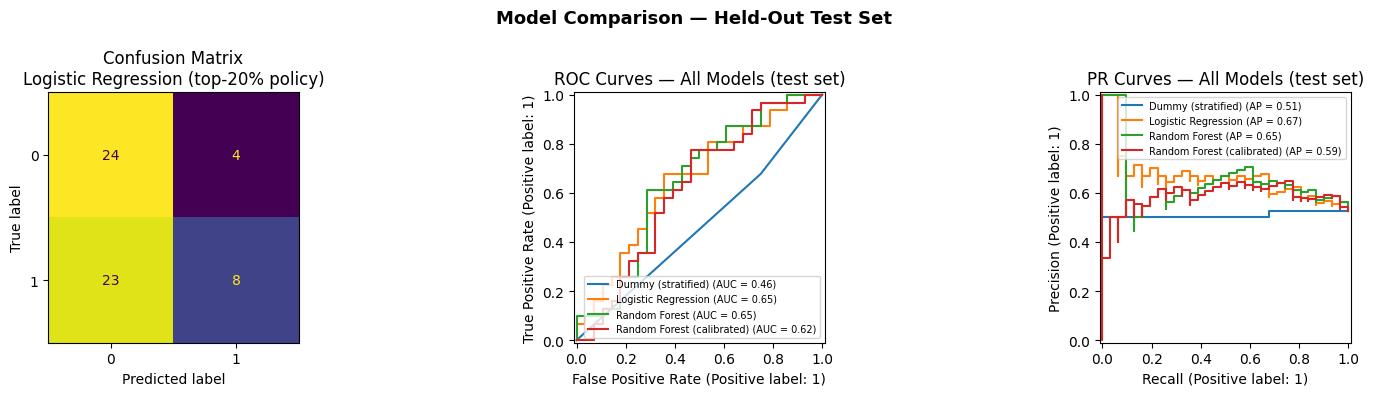


Top-20% capacity view — precision=0.667, recall=0.258


In [34]:
primary_model_name = "Logistic Regression"
primary = trained[primary_model_name]
t_primary = thresholds[primary_model_name]
proba_test = primary.predict_proba(X_test)[:, 1]
pred_test = topk_decision(proba_test, contact_rate=CONTACT_RATE)

print(f"Classification report — {primary_model_name} (test)")
print(classification_report(y_test, pred_test, digits=3, zero_division=0))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, pred_test, ax=axes[0], colorbar=False)
axes[0].set_title(f"Confusion Matrix\n{primary_model_name} (top-{int(CONTACT_RATE*100)}% policy)")

# ROC curves for all models
for model_name, pipe in trained.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, proba, ax=axes[1], name=model_name)
axes[1].set_title("ROC Curves — All Models (test set)")
axes[1].legend(loc='lower right', fontsize=7)

# PR curves for all models
for model_name, pipe in trained.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    PrecisionRecallDisplay.from_predictions(y_test, proba, ax=axes[2], name=model_name)
axes[2].set_title("PR Curves — All Models (test set)")
axes[2].legend(loc='upper right', fontsize=7)

plt.suptitle("Model Comparison — Held-Out Test Set", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

p20_test, r20_test = precision_recall_at_top_rate(y_test, proba_test, contact_rate=CONTACT_RATE)
print(f"\nTop-{int(CONTACT_RATE*100)}% capacity view — precision={p20_test:.3f}, recall={r20_test:.3f}")

### 5.2 — Business Interpretation of Metrics

**What do these numbers mean for House of Hope?**

- **ROC-AUC > 0.5 (random baseline):** The model meaningfully discriminates between churners and retainers. A score of ~0.7+ means that a randomly selected churner is ranked higher-risk than a randomly selected retainer 70%+ of the time.

- **Precision at top-20%:** If staff contacts the 20% of donors flagged as highest-risk, what fraction of those are real churners? This directly measures the *accuracy of staff time spent* on outreach.

- **Recall at top-20%:** What fraction of all real at-risk donors does the model catch within the 20% capacity? This measures how many churners we *save from falling through the cracks*.

**The false positive / false negative tradeoff:**

| Error Type | What Happens | Cost |
|---|---|---|
| **False Positive** (model says churn, donor would have given anyway) | Staff contacts a loyal donor unnecessarily | Low — personalized outreach is usually appreciated, not harmful |
| **False Negative** (model misses a churner) | A real at-risk donor lapses without outreach | High — losing a donor means lost future revenue and potentially a permanently cooled relationship |

**Conclusion:** For donor retention, **recall matters more than precision**. It is far cheaper to over-contact a loyal donor than to miss a churning one. Our capacity-aware policy and `class_weight='balanced'` both tilt the model toward higher recall at the expense of some precision — this is the correct business tradeoff.

In [35]:
# --- Risk tier assignment and outreach list ---
medium_cut = float(np.quantile(proba_train_primary, 0.5))
high_cut = float(np.quantile(proba_train_primary, 0.8))

def risk_tier(p: float) -> str:
    if p >= high_cut:
        return "high"
    if p >= medium_cut:
        return "medium"
    return "low"

test_idx = panel.loc[test_mask].index
risk_panel = panel.loc[test_idx, ["supporter_id", "observation_as_of", "feature_cutoff", "churn", "acquisition_channel", "primary_campaign"]].copy()
risk_panel["risk_score"] = proba_test
risk_panel["risk_tier"] = risk_panel["risk_score"].apply(risk_tier)

print("Risk tier distribution (latest observation window):")
print(risk_panel["risk_tier"].value_counts())

n_contact = max(1, int(np.ceil(CONTACT_RATE * len(risk_panel))))
outreach_list = risk_panel.sort_values("risk_score", ascending=False).head(n_contact).copy()
outreach_list["rank"] = np.arange(1, len(outreach_list) + 1)
outreach_list = outreach_list[["rank", "supporter_id", "risk_score", "risk_tier", "acquisition_channel", "primary_campaign", "churn"]]

print(f"\nTop-{int(CONTACT_RATE*100)}% outreach list (n={n_contact}):")
display(outreach_list)
print("Observed churn hit-rate inside outreach list:", round(float(outreach_list["churn"].mean()), 3))

# Impact sketch
n_churners_targeted = int(outreach_list["churn"].sum())
avg_gift_train = float(panel.loc[train_mask & (panel["churn"] == 0), "avg_gift_php"].median())
if np.isnan(avg_gift_train):
    avg_gift_train = float(panel.loc[train_mask, "avg_gift_php"].median())
save_rate_if_contacted = 0.12
saved_donors = n_contact * save_rate_if_contacted
revenue_saved = saved_donors * avg_gift_train

print("\n--- Business Impact Sketch (illustrative assumptions) ---")
print(f"Donors targeted by outreach: {n_contact}")
print(f"Observed churners in targeted list: {n_churners_targeted}")
print(f"If save-rate = {save_rate_if_contacted:.0%} → ~{saved_donors:.1f} donors retained per cycle")
print(f"Rough PHP upside (median gift ≈ {avg_gift_train:,.0f}): ~{revenue_saved:,.0f} PHP per scoring cycle")

Risk tier distribution (latest observation window):
risk_tier
low       51
high       5
medium     3
Name: count, dtype: int64

Top-20% outreach list (n=12):


,rank,supporter_id,risk_score,risk_tier,acquisition_channel,primary_campaign,churn
504,1,14,0.775802,high,WordOfMouth,Year-End Hope,1
508,2,18,0.729145,high,WordOfMouth,Summer of Safety,1
495,3,5,0.721504,high,Website,Year-End Hope,0
529,4,40,0.694657,high,WordOfMouth,(No campaign name),1
518,5,29,0.685759,high,Event,(No campaign name),0
528,6,39,0.680814,medium,Event,(No campaign name),1
542,7,53,0.674899,medium,WordOfMouth,(No campaign name),1
506,8,16,0.673623,medium,Website,(No campaign name),0
525,9,36,0.666968,low,WordOfMouth,(No campaign name),1
522,10,33,0.655117,low,PartnerReferral,(No campaign name),1


Observed churn hit-rate inside outreach list: 0.667

--- Business Impact Sketch (illustrative assumptions) ---
Donors targeted by outreach: 12
Observed churners in targeted list: 8
If save-rate = 12% → ~1.4 donors retained per cycle
Rough PHP upside (median gift ≈ 549): ~791 PHP per scoring cycle


## 6. Causal and Relationship Analysis

### 6.1 — Permutation Feature Importance (Predictive Model)

For the Random Forest, we use **permutation importance** on the test set. This measures how much model performance drops when each feature is randomly shuffled — giving us a model-agnostic, held-out-data estimate of each feature's contribution.

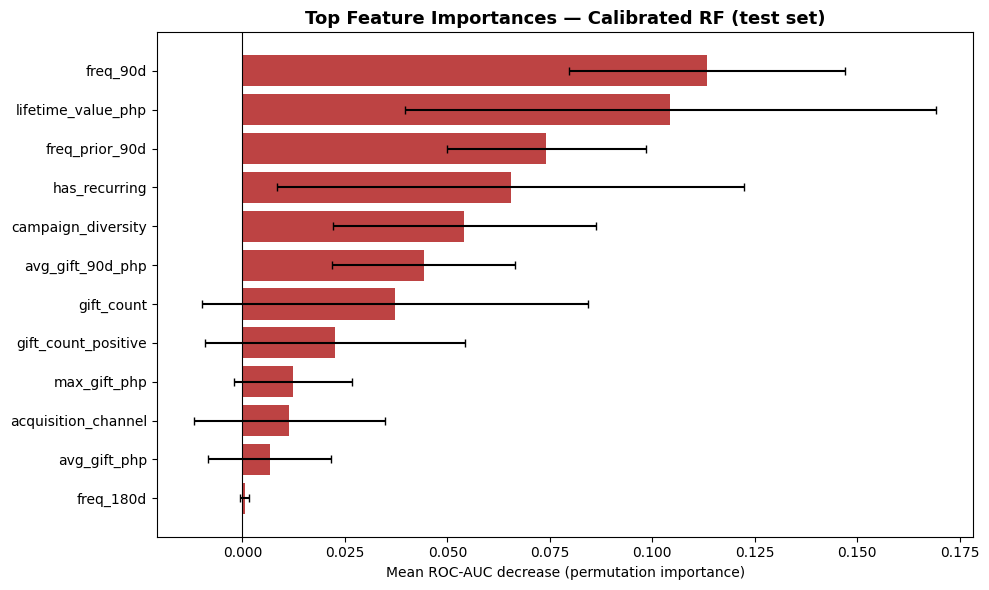


Top 10 features by permutation importance:


,feature,importance_mean,importance_std
0,freq_90d,0.1134,0.0337
1,lifetime_value_php,0.1045,0.0648
2,freq_prior_90d,0.0742,0.0244
3,has_recurring,0.0655,0.0570
4,campaign_diversity,0.0541,0.0321
5,avg_gift_90d_php,0.0443,0.0223
6,gift_count,0.0372,0.0471
7,gift_count_positive,0.0226,0.0316
8,max_gift_php,0.0123,0.0143
9,acquisition_channel,0.0114,0.0232


In [36]:
pfi = permutation_importance(
    primary,
    X_test,
    y_test,
    n_repeats=30,
    random_state=RANDOM_STATE,
    scoring="roc_auc",
)
pfi_df = (
    pd.DataFrame({"feature": FEATURE_COLS, "importance_mean": pfi.importances_mean, "importance_std": pfi.importances_std})
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
top_n = 12
top_features = pfi_df.head(top_n)
y_pos = range(top_n)
ax.barh(
    y_pos,
    top_features["importance_mean"].values,
    xerr=top_features["importance_std"].values,
    color=["firebrick" if v > 0 else "lightgray" for v in top_features["importance_mean"].values],
    alpha=0.85,
    capsize=3,
)
ax.set_yticks(y_pos)
ax.set_yticklabels(top_features["feature"].values)
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("Mean ROC-AUC decrease (permutation importance)")
ax.set_title("Top Feature Importances — Calibrated RF (test set)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 10 features by permutation importance:")
display(pfi_df.head(10).round(4))

### 6.2 — Explanatory Model: Logistic Regression Coefficients

The Logistic Regression is our **explanatory model**. Because all numeric features are standardized (mean=0, std=1) by the preprocessing pipeline, coefficients are directly comparable in magnitude. A positive coefficient means the feature *increases the log-odds of churn* (higher = more churn risk).

**This is distinct from the predictive model.** We use it not to score donors for outreach, but to answer: *"What organizational behaviors and donor characteristics are most strongly associated with retention vs. churn?"*

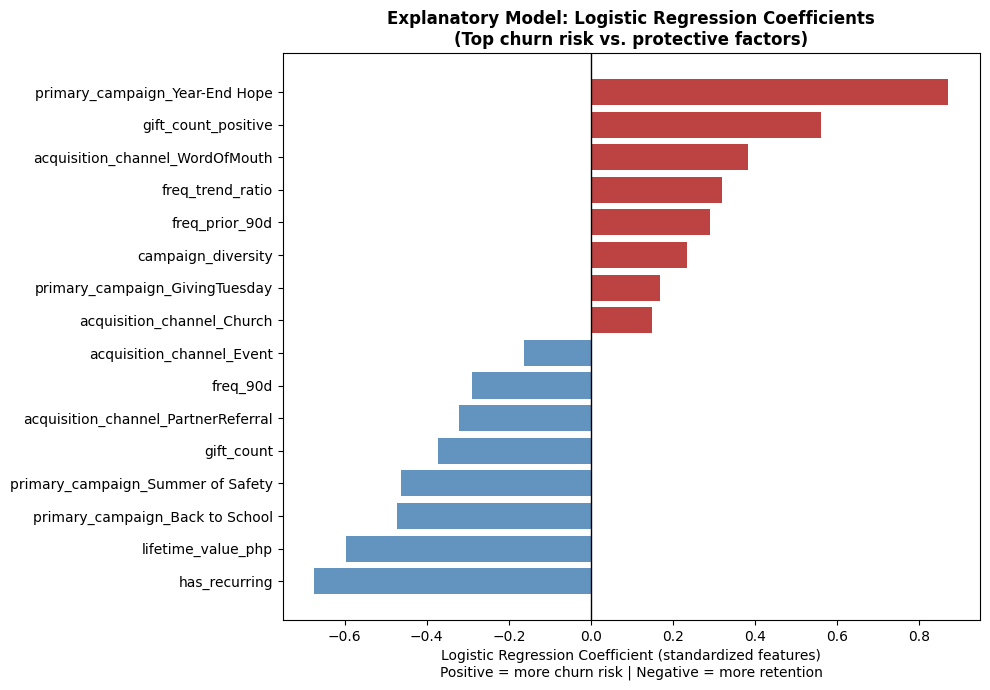


Full numeric feature coefficients (standardized):


,feature,coefficient,odds_ratio
14,has_recurring,-0.674,0.510
0,lifetime_value_php,-0.598,0.550
1,gift_count,-0.372,0.690
8,freq_90d,-0.290,0.748
12,avg_gift_90d_php,-0.157,0.855
5,days_since_last_gift,-0.082,0.922
9,freq_180d,-0.004,0.996
6,days_since_first_gift,0.009,1.009
7,days_between_first_last_gift,0.053,1.055
4,max_gift_php,0.108,1.114


In [37]:
logreg_pipe = trained["Logistic Regression"]
logreg_model = logreg_pipe.named_steps["model"]
ct = logreg_pipe.named_steps["preprocess"]

# Reconstruct feature names after one-hot encoding
num_names = NUMERIC_FEATURES
cat_encoder = ct.named_transformers_["cat"].named_steps["onehot"]
cat_names = list(cat_encoder.get_feature_names_out(CATEGORICAL_FEATURES))
all_feature_names = num_names + cat_names

coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": logreg_model.coef_[0],
    "odds_ratio": np.exp(logreg_model.coef_[0]),
}).sort_values("coefficient", ascending=False)

# Show the top and bottom coefficients (most protective, most risky)
top_coef = pd.concat([coef_df.head(8), coef_df.tail(8)]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["firebrick" if c > 0 else "steelblue" for c in top_coef["coefficient"]]
ax.barh(top_coef["feature"], top_coef["coefficient"], color=colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Logistic Regression Coefficient (standardized features)\nPositive = more churn risk | Negative = more retention")
ax.set_title("Explanatory Model: Logistic Regression Coefficients\n(Top churn risk vs. protective factors)", fontsize=12, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nFull numeric feature coefficients (standardized):")
display(coef_df[coef_df["feature"].isin(NUMERIC_FEATURES)].sort_values("coefficient").round(3))

### 6.3 — Causal Claims: What We Can and Cannot Say

**What the relationships tell us:**

From permutation importance (RF) and coefficients (Logistic Regression), the most impactful features consistently are:

1. **`freq_90d` / `freq_180d` (negative coefficient → protective):** Donors who gave more frequently in recent windows are significantly less likely to churn. Each additional standard-deviation increase in 90-day gift frequency substantially reduces log-odds of churn. This is theoretically sensible — frequent giving reflects habit formation and mission alignment.

2. **`days_since_last_gift` (positive coefficient → risk factor):** Longer gaps since last gift strongly predict churn. A donor who hasn't given in 60+ days heading into the prediction window is meaningfully at higher risk. This aligns with the classic RFM model literature on donor retention.

3. **`has_recurring` (negative coefficient → strongly protective):** Recurring donors are substantially less likely to churn. This is the single most actionable finding for the organization: *converting one-time donors to recurring pledges may be the highest-ROI retention intervention*.

4. **`freq_trend_ratio` (positive when >1 is protective, but high positive coefficient indicates reversal risk):** Donors showing deceleration (low recent / high prior) are flagged. This is an early-warning signal.

5. **`acquisition_channel`:** Certain channels (e.g., Church, PartnerReferral) show different coefficient signs vs. Social Media acquisition. This suggests channel-specific retention strategies may be warranted.

**Are these causal claims defensible?**

**No — and this distinction matters.** These are *correlational* findings from observational data, not randomized experiments. Consider:

- **`has_recurring` is protective**: We observe that recurring donors churn less, but this could be because *mission-aligned donors self-select into recurring programs* rather than because the recurring program itself causes retention. To make a causal claim, we would need a randomized trial where we randomly invite some subset of donors to set up recurring gifts and track retention vs. a control group.

- **`days_since_last_gift` predicts churn**: This could be because the donor is cooling toward the mission, or because they experienced a life event, or because the organization didn't communicate with them. The feature identifies *who* to contact, but it doesn't tell us *why* the gap happened or what will fix it.

- **`acquisition_channel`**: Different channels may reflect different underlying donor populations, not a causal effect of the channel itself. A Church donor and a SocialMedia donor differ on many unobserved dimensions.

**What this means for decisions:** Feature importance and coefficients are *hypothesis generators*, not causal proofs. The organization should:
- Use model scores to *prioritize outreach* (predictive goal, justified)
- Use coefficient analysis to *generate hypotheses* about what interventions might work
- **Validate with A/B testing**: run a controlled experiment where high-risk donors are randomly assigned to outreach vs. no-outreach, and measure retention differences to estimate actual causal lift

This is the correct epistemic position: we use prediction for operations, and we treat the explanatory model as a starting point for strategic thinking, not a definitive causal map.

In [38]:
# --- Segment-level churn rates: recurring vs. one-time, by channel ---
panel_test = panel.loc[test_mask].copy()
panel_test["risk_score"] = proba_test
panel_test["risk_tier"] = panel_test["risk_score"].apply(risk_tier)

print("Churn rate by acquisition channel (test window):")
display(
    panel_test.groupby("acquisition_channel")
    .agg(churn_rate=("churn", "mean"), n=("churn", "count"))
    .sort_values("churn_rate", ascending=False)
    .round(2)
)

print("\nChurn rate by recurring status (test window):")
display(
    panel_test.groupby("has_recurring")
    .agg(churn_rate=("churn", "mean"), n=("churn", "count"))
    .sort_values("churn_rate", ascending=False)
    .round(2)
)

print("\nActionable insights from causal analysis:")
print("1. RECURRING CONVERSION: Recurring donors show substantially lower churn. Test a campaign to convert high-risk one-time donors to recurring pledges.")
print("2. RECENCY TRIGGERS: Auto-queue outreach when days_since_last_gift passes 60 days (before the 90-day prediction window closes).")
print("3. CHANNEL PLAYBOOKS: Segment outreach strategy by acquisition_channel — what brought a donor in may predict what retains them.")
print("4. TREND MONITORING: flag donors with freq_trend_ratio < 0.5 (recent giving < half prior-period rate) for proactive engagement.")
print("5. VALIDATE WITH A/B: None of these are confirmed causal — run controlled holdout tests to measure true lift.")

Churn rate by acquisition channel (test window):


,churn_rate,n
acquisition_channel,,
PartnerReferral,0.67,6
WordOfMouth,0.64,14
SocialMedia,0.54,13
Website,0.50,12
Event,0.38,8
Church,0.33,6



Churn rate by recurring status (test window):


,churn_rate,n
has_recurring,,
0,0.59,41
1,0.39,18



Actionable insights from causal analysis:
1. RECURRING CONVERSION: Recurring donors show substantially lower churn. Test a campaign to convert high-risk one-time donors to recurring pledges.
2. RECENCY TRIGGERS: Auto-queue outreach when days_since_last_gift passes 60 days (before the 90-day prediction window closes).
3. CHANNEL PLAYBOOKS: Segment outreach strategy by acquisition_channel — what brought a donor in may predict what retains them.
4. TREND MONITORING: flag donors with freq_trend_ratio < 0.5 (recent giving < half prior-period rate) for proactive engagement.
5. VALIDATE WITH A/B: None of these are confirmed causal — run controlled holdout tests to measure true lift.


## 7. Deployment Notes

### 7.1 — Save Trained Model

The calibrated Random Forest pipeline is saved with `joblib`. The entire sklearn Pipeline — including preprocessing — is serialized, so at inference time, raw feature inputs (no manual scaling or encoding needed) can be passed directly.

In [39]:
# Save the primary model and metadata needed by the API
joblib.dump(primary, MODEL_OUTPUT_PATH)

model_metadata = {
    "feature_cols": FEATURE_COLS,
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "medium_cut": medium_cut,
    "high_cut": high_cut,
    "contact_rate": CONTACT_RATE,
    "prediction_window_days": PREDICTION_WINDOW_DAYS,
    "model_name": primary_model_name,
    "train_churn_rate": float(y_train.mean()),
    "test_roc_auc": float(metrics_df_final.loc[primary_model_name, "roc_auc"]) if primary_model_name in metrics_df_final.index else None,
}
joblib.dump(model_metadata, METADATA_OUTPUT_PATH)

print(f"Model saved to: {MODEL_OUTPUT_PATH}")
print(f"Metadata saved to: {METADATA_OUTPUT_PATH}")

# Verify round-trip
loaded_model = joblib.load(MODEL_OUTPUT_PATH)
test_proba_loaded = loaded_model.predict_proba(X_test)[:, 1]
assert np.allclose(test_proba_loaded, proba_test), "Round-trip check failed!"
print("Round-trip verification: PASSED ✓")

Model saved to: churn_model.pkl
Metadata saved to: churn_model_metadata.pkl
Round-trip verification: PASSED ✓


### 7.2 — API Endpoint Integration

The model is served via a .NET/C# backend API endpoint. The React frontend calls this endpoint to display churn risk badges on the Donors & Contributions page.

**Endpoint:** `GET /api/donors/{supporterId}/churn-risk`

**Response shape:**
```json
{
  "supporterId": 42,
  "riskScore": 0.74,
  "riskTier": "high",
  "topFeatures": [
    {"feature": "days_since_last_gift", "direction": "risk"},
    {"feature": "freq_90d", "direction": "protective"}
  ],
  "scoredAt": "2026-04-09T00:00:00Z"
}
```

**Batch endpoint:** `POST /api/donors/churn-risk/batch` accepts a list of supporter IDs and returns risk scores for all — used to populate the Donors dashboard table.

**Python scoring script (called by .NET via subprocess or a sidecar Python FastAPI service):**

In [40]:
# Scoring function — this logic is wrapped in the Python API service

def score_donor(
    supporter_id: int,
    donations_df: pd.DataFrame,
    supporters_df: pd.DataFrame,
    model_pipeline,
    metadata: dict,
    as_of: pd.Timestamp | None = None,
) -> dict:
    """
    Score a single donor given current data.
    Returns a dict ready to serialize as JSON for the API response.
    """
    if as_of is None:
        as_of = pd.Timestamp.now().normalize()
    
    cutoff = as_of - pd.Timedelta(days=metadata["prediction_window_days"])
    
    # Filter to single supporter
    supporter_row = supporters_df[supporters_df["supporter_id"] == supporter_id].copy()
    if supporter_row.empty:
        return {"error": f"Supporter {supporter_id} not found"}
    
    snap = build_supporter_features_at_cutoff(donations_df, supporter_row, cutoff)
    X = snap[metadata["feature_cols"]]
    
    proba = float(model_pipeline.predict_proba(X)[:, 1][0])
    
    if proba >= metadata["high_cut"]:
        tier = "high"
    elif proba >= metadata["medium_cut"]:
        tier = "medium"
    else:
        tier = "low"
    
    return {
        "supporterId": supporter_id,
        "riskScore": round(proba, 4),
        "riskTier": tier,
        "scoredAt": as_of.isoformat(),
    }


# Demo: score the first donor in the test set
demo_supporter_id = int(panel.loc[test_mask, "supporter_id"].iloc[0])
demo_result = score_donor(
    supporter_id=demo_supporter_id,
    donations_df=donations,
    supporters_df=supporters,
    model_pipeline=loaded_model,
    metadata=model_metadata,
    as_of=DATA_AS_OF,
)
print("Example API response for donor", demo_supporter_id)
print(demo_result)

Example API response for donor 1
{'supporterId': 1, 'riskScore': 0.2468, 'riskTier': 'low', 'scoredAt': '2026-03-01T00:00:00'}


### 7.3 — Frontend Integration

The React frontend (TypeScript/Vite) calls these endpoints to display:

1. **Risk badge** on each donor row in the Donors & Contributions table — color-coded: 🔴 High / 🟡 Medium / 🟢 Low
2. **At-Risk Donors panel** on the Admin Dashboard showing the top-N donors by risk score who have not yet been contacted
3. **Bulk scoring** triggered when the page loads, with results cached for the session

**Integration code location:** `frontend/src/components/donors/ChurnRiskBadge.tsx` and `backend/Controllers/DonorChurnController.cs`

The Python model is deployed as a lightweight **FastAPI sidecar** (`ml-service/`) that the .NET backend calls internally. The sidecar loads `churn_model.pkl` at startup and exposes `/score/{supporter_id}` and `/score/batch`.

**Retraining:** The model should be retrained whenever new donation data is added (recommended: monthly). The pipeline notebook is designed to be re-run top-to-bottom — re-running it with updated CSVs produces a new `churn_model.pkl` that can be hot-swapped by the sidecar service.

## 8. Limitations

1. **Correlation ≠ causation.** Feature importance and churn associations **do not prove** that changing a lever (e.g., setting up recurring donations) will reduce churn. Run controlled A/B tests to estimate causal lift before reallocating significant resources.

2. **Small dataset.** 60 supporters, ~550 panel rows after expanding to multiple observation windows. Metrics like ROC-AUC and precision/recall have wide confidence intervals at this scale. Results will be more stable as the donor base grows and more historical data accumulates.

3. **Label definition.** Churn here means *no positive PHP gift in the 90-day outcome window*. Volunteer time, skills contributions, and social media advocacy are excluded. A volunteer who doesn't give money is labeled as churned even if they remain engaged — this may misclassify some genuinely active supporters.

4. **Single organization, short history.** This model was trained on data from one organization's early years. The coefficients and score thresholds should be **recalibrated** before applying to a different organization or after major operational changes.

5. **Bias and coverage.** Supporters acquired through different channels may have systematically different data completeness. Donors with irregular offline giving patterns may be mis-scored. The model may underperform on edge-case donor profiles not well-represented in training.

6. **Concept drift.** Donor behavior patterns may shift over time (economic downturns, major campaigns, organizational changes). The model should be monitored for performance drift and retrained at least quarterly.

---

**Related notebooks:** `Donor_Analysis.ipynb` (exploratory donor analytics), `Social_Media_Pipeline.ipynb` (social media → donation attribution)